# Undersampling plus class correction: experiments

We'll use the hospital admissions dataset that is available at the UCI Machine Learning Repository.

The dataset contains ten years of clinical care records from 130 US hospitals. Each row is a hospital record consisting of a patient diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The target registers if the patient had to be readmitted to hospital after being discharged.

The goal is to determine the early readmission of the patient (whether they returned to hospital within 30 days of discharge). The positive class is those patients who came back to hospital within 30 days of being released.

[UCI Diabetes 130-US Hospitals](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from feature_engine.encoding import OrdinalEncoder
from feature_engine.selection import DropConstantFeatures

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import LearningCurveDisplay, train_test_split 

## Load diabetes dataset

In [2]:
df = pd.read_csv("diabetic_data.csv")
print(f"Data size: {df.shape}")
df.head()

Data size: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Target: Admissions

In [3]:
# target
y = df["readmitted"]
y = np.where(y == "<30", 1, 0)

minority = y.sum()
majority = (len(y) - minority)

prevalence = np.round(y.mean(), 4)
ir = np.round(majority/minority, 2)

print(f"prevalence: {prevalence}")
print(f"IR: {ir}")

prevalence: 0.1116
IR: 7.96


## Features

In [4]:
# remove target plus id columns
cols_to_drop = ["readmitted", "encounter_id", "patient_nbr"]
X = df.drop(cols_to_drop, axis=1)

# categorical variables
cat_vars = X.select_dtypes(include="object").columns.tolist()
print(f"Number of categorical variables: {len(cat_vars)}")

# impute nan and encode categorical vars
X[cat_vars] = X[cat_vars].fillna("Missing")
X = OrdinalEncoder(
    encoding_method="arbitrary", variables=cat_vars
).fit_transform(X)

X = DropConstantFeatures().fit_transform(X)
X.shape

Number of categorical variables: 36


/var/folders/n4/2v690vyd1rd0c0rjks_7_fhc0000gn/T/ipykernel_42474/1122175466.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_vars = X.select_dtypes(include="object").columns.tolist()


(101766, 45)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=0)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

np.mean(y_train), np.mean(y_test)

Train set size: (61059, 45)
Test set size: (40707, 45)


(np.float64(0.1117443783881164), np.float64(0.1113813349055445))

## Learning curve original distributions

The dataset is quite big so we'll examine the learning curve to determine the minimum size required for a reliable model.

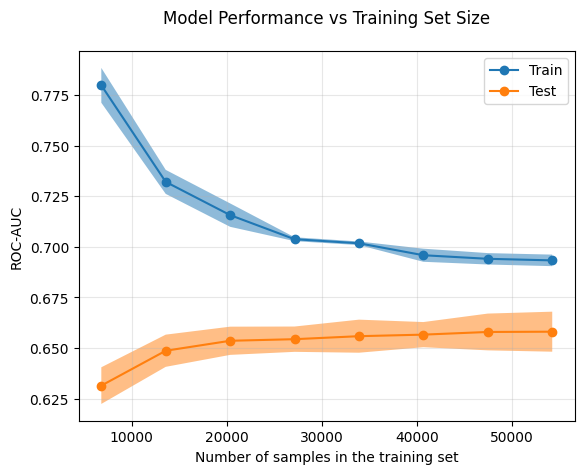

In [6]:
model = GradientBoostingClassifier(random_state=0)

train_sizes = [.1, .2, .3, .4, .5, .6, .7, .8]

LearningCurveDisplay.from_estimator(
    model,
    X, y, 
    train_sizes=train_sizes, 
    cv=3,
    scoring='roc_auc',
    shuffle=True,     # <--- shuffles the training folds before slicing
    random_state=0,   # <--- Guarantees reproducibility of the shuffles
    line_kw = {"marker": "o"},
)

plt.title('Model Performance vs Training Set Size', pad=20)
plt.ylabel('ROC-AUC')
plt.grid(alpha=0.3)
# plt.savefig("../../mlid-book/resources/ch5/ch5-fig1.png", dpi=300, bbox_inches="tight")
plt.show()

With half of the dataset we should obtain a reliable model.

## Learning curve undersampling

With big datasets, undersampling may help improve training speed. To this end, keeping all of the positive examples, which are usually precious, we'll examine how much of the majority class we need to obtain reliable models.

In [7]:
# sanity check: the dictionaries for RUS need to have
# the number of desired examples of each class

for ratio in range(1,5):
    minority = int(np.sum(y_train)/3)
    majority = minority * ratio
    us_dict = {1:minority, 0:majority}
    print(us_dict)

{1: 2274, 0: 2274}
{1: 2274, 0: 4548}
{1: 2274, 0: 6822}
{1: 2274, 0: 9096}


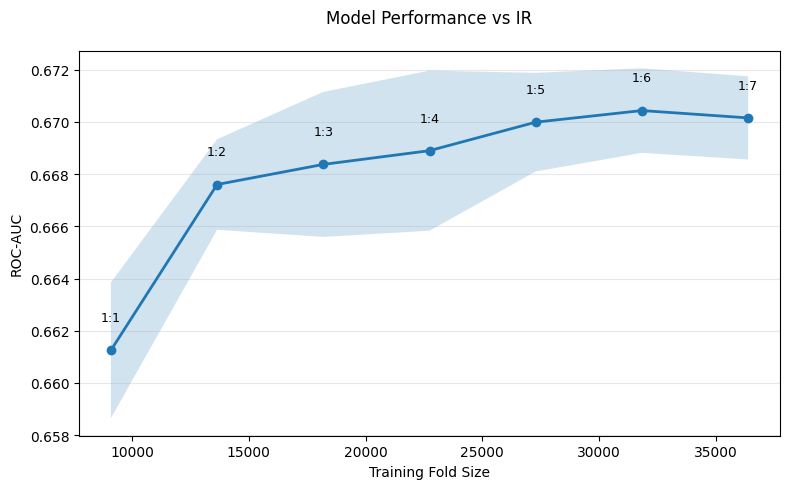

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

roc_auc_scores, roc_auc_stds, dataset_sizes = [], [], []

for ratio in range(1,8):
    
    # define number of minority and majority in training set
    # 2 of the 3 cv folds
    minority = int(np.sum(y_train)/3*2)
    majority = minority * ratio
    us_dict = {1:minority, 0:majority}

    # pipeline, so cross-validate tests in original data distribution
    model = Pipeline([
        ('us', RandomUnderSampler(sampling_strategy=us_dict, random_state=0)),
        ('cls', GradientBoostingClassifier(random_state=0))
    ])
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    roc_auc_scores.append(scores.mean())
    roc_auc_stds.append(scores.std())

    # Calculate total dataset size after undersampling
    dataset_size = minority + majority
    dataset_sizes.append(dataset_size)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(dataset_sizes, roc_auc_scores, marker='o', linewidth=2, markersize=6)
plt.fill_between(dataset_sizes, 
                 [score - std for score, std in zip(roc_auc_scores, roc_auc_stds)],
                 [score + std for score, std in zip(roc_auc_scores, roc_auc_stds)],
                 alpha=0.2)

# Annotate IR on top of dots
for size, score, ratio in zip(dataset_sizes, roc_auc_scores, range(1, 8)):
    plt.text(size, score + 0.001, f'1:{ratio}', ha='center', va='bottom', fontsize=9)


plt.title('Model Performance vs IR', pad=20)
plt.ylabel('ROC-AUC')
plt.xlabel('Training Fold Size')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Test model performance and training speed

We want to understand if reducing data size helps us train models faster.

In [9]:
import time
from sklearn.metrics import roc_auc_score, log_loss

### Without resampling

In [10]:
results = {
    'training_set_size': [],
    'roc_auc_mean': [],
    'roc_auc_std': [],
    'logloss_mean': [],
    'logloss_std': [],
    'training_time_mean': [],
    'training_time_std': []
}

for train_size in ['full', 'half']:
    
    if train_size == 'full':
        X_train_subset = X_train.values
        y_train_subset = y_train
    else:
        X_train_subset = X_train.values[:len(X_train)//2]
        y_train_subset = y_train[:len(y_train)//2]
    
    roc_scores = []
    logloss_scores = []
    train_times = []
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    
    for train_idx, test_idx in cv.split(X_train_subset, y_train_subset):
        X_cv_train = X_train_subset[train_idx]
        X_cv_test = X_train_subset[test_idx]
        y_cv_train = y_train_subset[train_idx]
        y_cv_test = y_train_subset[test_idx]
        
        model = GradientBoostingClassifier(random_state=0)
        
        start_time = time.time()
        model.fit(X_cv_train, y_cv_train)
        train_time = time.time() - start_time
        train_times.append(train_time)
        
        y_pred_proba = model.predict_proba(X_cv_test)[:, 1]
        roc_auc = roc_auc_score(y_cv_test, y_pred_proba)
        roc_scores.append(roc_auc)
        ll = log_loss(y_cv_test, y_pred_proba)
        logloss_scores.append(ll)
    
    results['training_set_size'].append(train_size)
    results['roc_auc_mean'].append(np.mean(roc_scores))
    results['roc_auc_std'].append(np.std(roc_scores))
    results['logloss_mean'].append(np.mean(logloss_scores))
    results['logloss_std'].append(np.std(logloss_scores))
    results['training_time_mean'].append(np.mean(train_times))
    results['training_time_std'].append(np.std(train_times))

df_ = pd.DataFrame(results)
df_

,training_set_size,roc_auc_mean,roc_auc_std,logloss_mean,logloss_std,training_time_mean,training_time_std
0,full,0.670364,0.001845,0.330939,0.000516,4.268828,0.010101
1,half,0.662055,0.007742,0.332836,0.002338,2.159257,0.014119


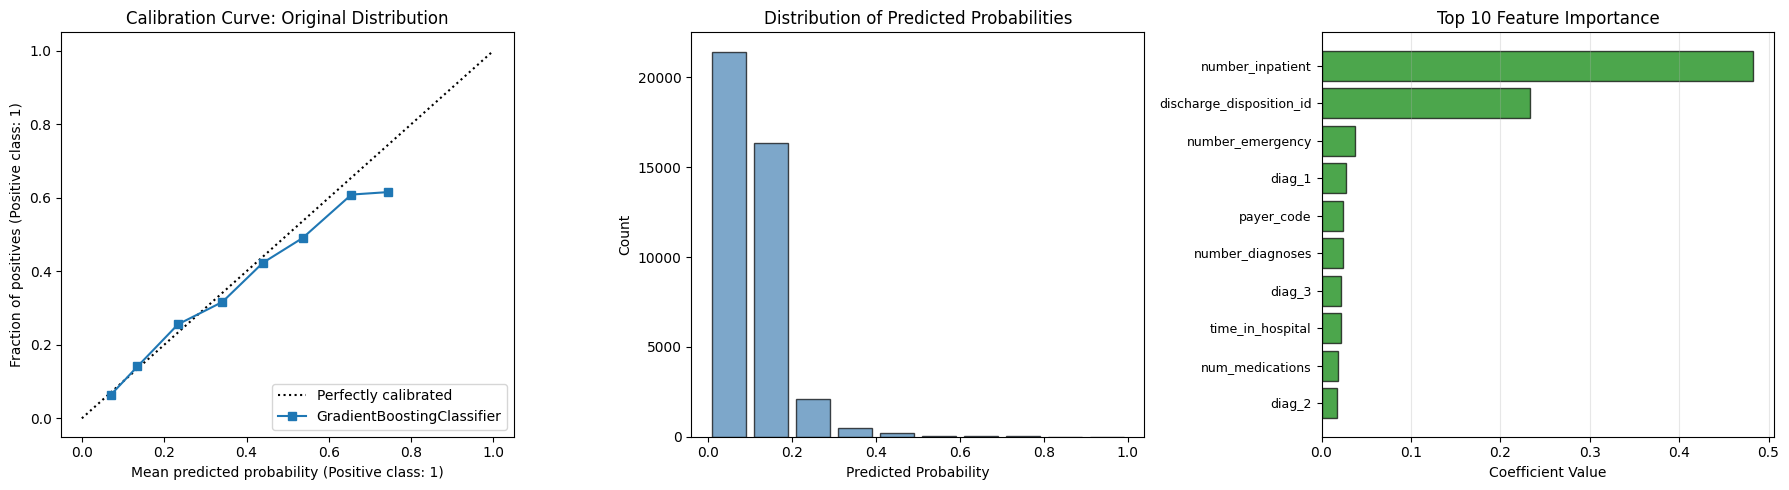

In [11]:
## Plot calibration curve, bar plot with number of samples per bin of probability distribution, and feature importance

model = GradientBoostingClassifier(random_state=0)
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Calibration curve
CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=axes[0])
axes[0].set_title('Calibration Curve: Original Distribution')

# Plot 2: Bar plot of predicted probabilities
bins = np.linspace(0, 1, 11)
counts, _ = np.histogram(probs, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = 0.08

axes[1].bar(bin_centers, counts, width=bin_width, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predicted Probabilities')

# Plot 3: Feature importance (top 10 features)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', key=abs, ascending=False).head(10)

feature_importance_sorted = feature_importance.sort_values('importance')

axes[2].barh(range(len(feature_importance_sorted)), feature_importance_sorted['importance'], 
            color=['green' if x > 0 else 'red' for x in feature_importance_sorted['importance']],
            edgecolor='black', alpha=0.7)
axes[2].set_yticks(range(len(feature_importance_sorted)))
axes[2].set_yticklabels(feature_importance_sorted['feature'], fontsize=9)
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('Top 10 Feature Importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
outputdir="../../mlid-book/resources/ch5/ch5-1.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

### With resampling

In [12]:
# the number of samples in 2 fold of cross-validation
minority = int(np.sum(y_train) / 3 * 2)

for ratio in [1, 3]:
    majority = minority * ratio
    us_dict = {1: minority, 0: majority}
    
    roc_scores = []
    train_times = []
    logloss_scores = []
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    
    for train_idx, test_idx in cv.split(X_train, y_train):
        X_cv_train = X_train.iloc[train_idx] 
        X_cv_test = X_train.iloc[test_idx]
        y_cv_train = y_train[train_idx]
        y_cv_test = y_train[test_idx]
        
        us = RandomUnderSampler(sampling_strategy=us_dict, random_state=0)
        X_us, y_us = us.fit_resample(X_cv_train, y_cv_train)
        
        model = GradientBoostingClassifier(random_state=0)
        
        start_time = time.time()
        model.fit(X_us, y_us)
        train_time = time.time() - start_time
        train_times.append(train_time)
        
        y_pred_proba = model.predict_proba(X_cv_test)[:, 1]
        roc_auc = roc_auc_score(y_cv_test, y_pred_proba)
        roc_scores.append(roc_auc)
        ll = log_loss(y_cv_test, y_pred_proba)
        logloss_scores.append(ll)
    
    results['training_set_size'].append(f'1:{ratio}')
    results['roc_auc_mean'].append(np.mean(roc_scores))
    results['roc_auc_std'].append(np.std(roc_scores))
    results['logloss_mean'].append(np.mean(logloss_scores))
    results['logloss_std'].append(np.std(logloss_scores))
    results['training_time_mean'].append(np.mean(train_times))
    results['training_time_std'].append(np.std(train_times))

df_ = pd.DataFrame(results)
df_

,training_set_size,roc_auc_mean,roc_auc_std,logloss_mean,logloss_std,training_time_mean,training_time_std
0,full,0.670364,0.001845,0.330939,0.000516,4.268828,0.010101
1,half,0.662055,0.007742,0.332836,0.002338,2.159257,0.014119
2,1:1,0.661248,0.002602,0.650574,0.002066,0.952809,0.001939
3,1:3,0.668373,0.002779,0.388199,0.000859,1.869157,0.017158


In [13]:
us_dict

{1: 4548, 0: 13644}

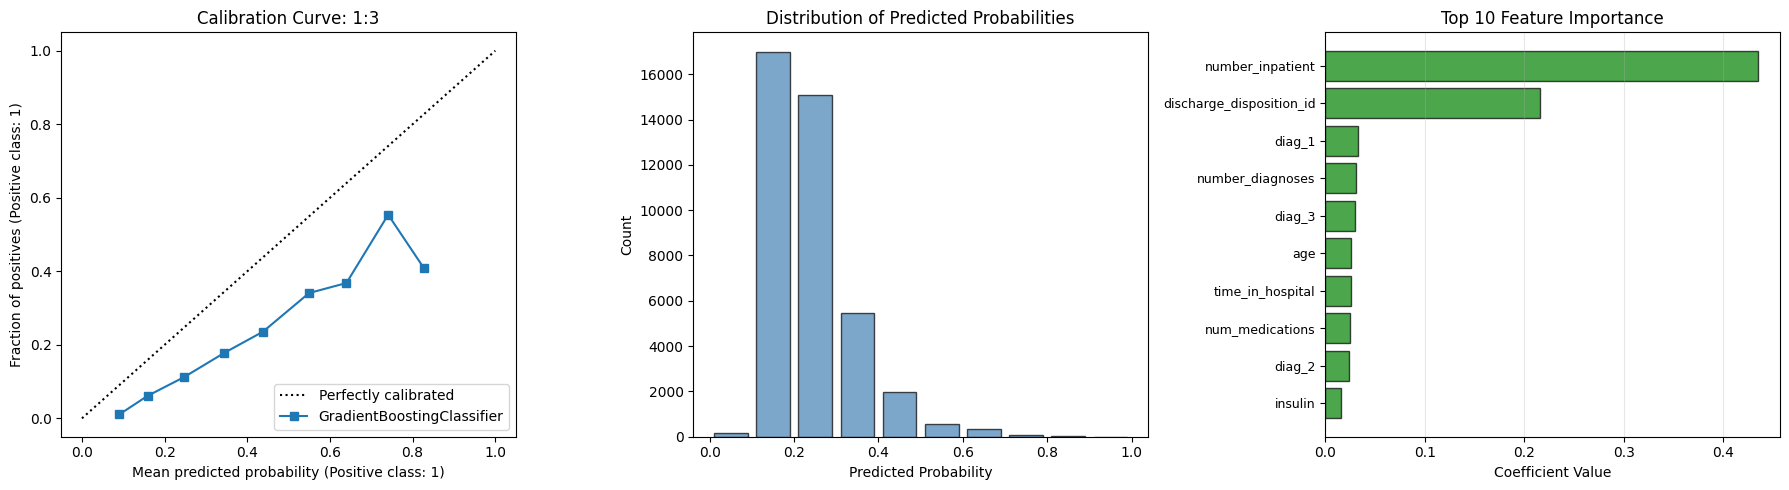

In [14]:
us = RandomUnderSampler(sampling_strategy=us_dict, random_state=0)
X_us, y_us = us.fit_resample(X_cv_train, y_cv_train)

model = GradientBoostingClassifier(random_state=0)
model.fit(X_us, y_us)
probs = model.predict_proba(X_test)[:, 1]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Calibration curve
CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=axes[0])
axes[0].set_title('Calibration Curve: 1:3')

# Plot 2: Bar plot of predicted probabilities
bins = np.linspace(0, 1, 11)
counts, _ = np.histogram(probs, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = 0.08

axes[1].bar(bin_centers, counts, width=bin_width, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predicted Probabilities')

# Plot 3: Feature importance (top 10 features)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', key=abs, ascending=False).head(10)

feature_importance_sorted = feature_importance.sort_values('importance')

axes[2].barh(range(len(feature_importance_sorted)), feature_importance_sorted['importance'], 
            color=['green' if x > 0 else 'red' for x in feature_importance_sorted['importance']],
            edgecolor='black', alpha=0.7)
axes[2].set_yticks(range(len(feature_importance_sorted)))
axes[2].set_yticklabels(feature_importance_sorted['feature'], fontsize=9)
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('Top 10 Feature Importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
outputdir="../../mlid-book/resources/ch5/ch5-2.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

### Restoring class prevalence

In [15]:
def define_weights(current_dist):

    class_weight_for_prevalence_correction = {
        0: (1 - prevalence) / (1 - current_dist),
        1: prevalence / current_dist,
    }

    return class_weight_for_prevalence_correction

In [16]:
# the number of samples in 2 fold of cross-validation
minority = int(np.sum(y_train) / 3 * 2)

for ratio in [1, 3]:
    majority = minority * ratio
    us_dict = {1: minority, 0: majority}
    
    roc_scores = []
    train_times = []
    logloss_scores = []
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    
    for train_idx, test_idx in cv.split(X_train, y_train):
        X_cv_train = X_train.iloc[train_idx] 
        X_cv_test = X_train.iloc[test_idx]
        y_cv_train = y_train[train_idx]
        y_cv_test = y_train[test_idx]
        
        us = RandomUnderSampler(sampling_strategy=us_dict, random_state=0)
        X_us, y_us = us.fit_resample(X_cv_train, y_cv_train)

        cw = define_weights(np.mean(y_us))
        sample_w = np.where(y_us == 0, cw[0], cw[1])
        
        model = GradientBoostingClassifier(random_state=0)
        
        start_time = time.time()
        model.fit(X_us, y_us, sample_weight=sample_w)
        train_time = time.time() - start_time
        train_times.append(train_time)
        
        y_pred_proba = model.predict_proba(X_cv_test)[:, 1]
        roc_auc = roc_auc_score(y_cv_test, y_pred_proba)
        roc_scores.append(roc_auc)
        ll = log_loss(y_cv_test, y_pred_proba)
        logloss_scores.append(ll)
    
    results['training_set_size'].append(f'1:{ratio} - restored')
    results['roc_auc_mean'].append(np.mean(roc_scores))
    results['roc_auc_std'].append(np.std(roc_scores))
    results['logloss_mean'].append(np.mean(logloss_scores))
    results['logloss_std'].append(np.std(logloss_scores))
    results['training_time_mean'].append(np.mean(train_times))
    results['training_time_std'].append(np.std(train_times))

df_ = pd.DataFrame(results)
df_

,training_set_size,roc_auc_mean,roc_auc_std,logloss_mean,logloss_std,training_time_mean,training_time_std
0,full,0.670364,0.001845,0.330939,0.000516,4.268828,0.010101
1,half,0.662055,0.007742,0.332836,0.002338,2.159257,0.014119
2,1:1,0.661248,0.002602,0.650574,0.002066,0.952809,0.001939
3,1:3,0.668373,0.002779,0.388199,0.000859,1.869157,0.017158
4,1:1 - restored,0.655775,0.002365,0.339181,0.001706,0.947239,0.000817
5,1:3 - restored,0.667515,0.001682,0.332870,0.000611,1.910085,0.078983


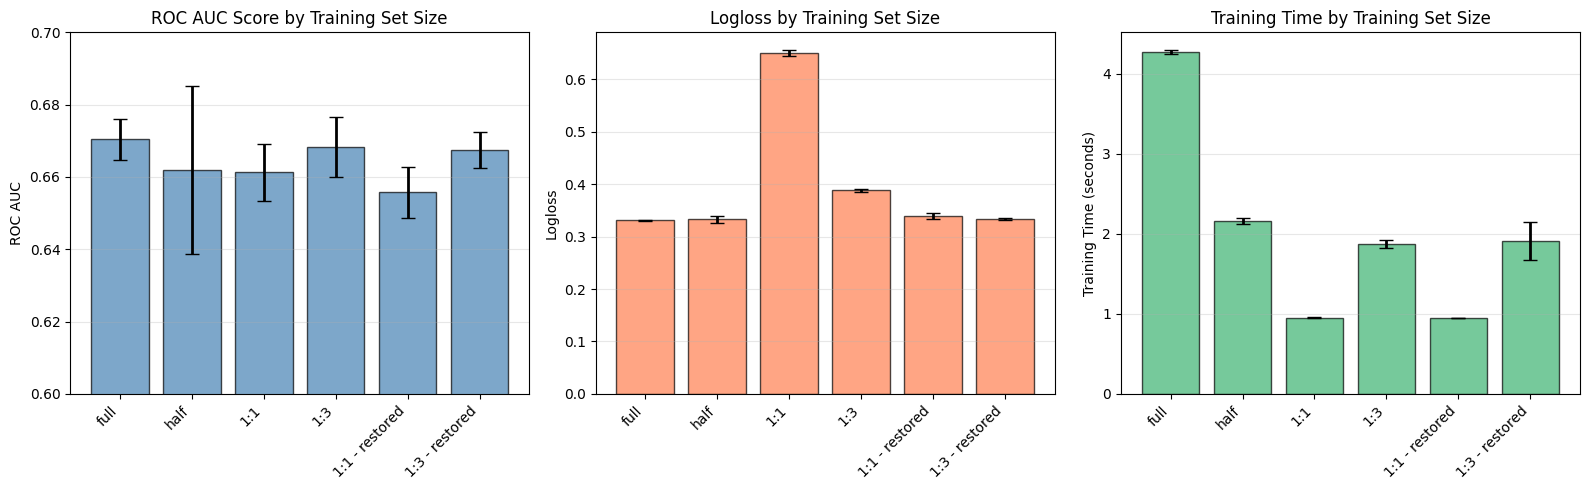

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: ROC AUC
axes[0].bar(range(len(df_)), df_['roc_auc_mean'], 
           yerr=3*df_['roc_auc_std'], capsize=5, 
           color='steelblue', edgecolor='black', alpha=0.7, error_kw={'elinewidth': 2})
axes[0].set_xticks(range(len(df_)))
axes[0].set_xticklabels(df_['training_set_size'], rotation=45, ha='right')
axes[0].set_ylabel('ROC AUC')
axes[0].set_ylim(0.6, 0.7)  # Set y-axis limits
axes[0].set_title('ROC AUC Score by Training Set Size')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Logloss
axes[1].bar(range(len(df_)), df_['logloss_mean'], 
           yerr=3*df_['logloss_std'], capsize=5, 
           color='coral', edgecolor='black', alpha=0.7, error_kw={'elinewidth': 2})
axes[1].set_xticks(range(len(df_)))
axes[1].set_xticklabels(df_['training_set_size'], rotation=45, ha='right')
axes[1].set_ylabel('Logloss')
axes[1].set_title('Logloss by Training Set Size')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Training Time
axes[2].bar(range(len(df_)), df_['training_time_mean'], 
           yerr=3*df_['training_time_std'], capsize=5, 
           color='mediumseagreen', edgecolor='black', alpha=0.7, error_kw={'elinewidth': 2})
axes[2].set_xticks(range(len(df_)))
axes[2].set_xticklabels(df_['training_set_size'], rotation=45, ha='right')
axes[2].set_ylabel('Training Time (seconds)')
axes[2].set_title('Training Time by Training Set Size')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Training on the full dataset gets the best performance. Training on a 1:3 undersampled version of the dataset seems to reach a similar performance while reducing the training speed by more than half.  

In [18]:
us_dict

{1: 4548, 0: 13644}

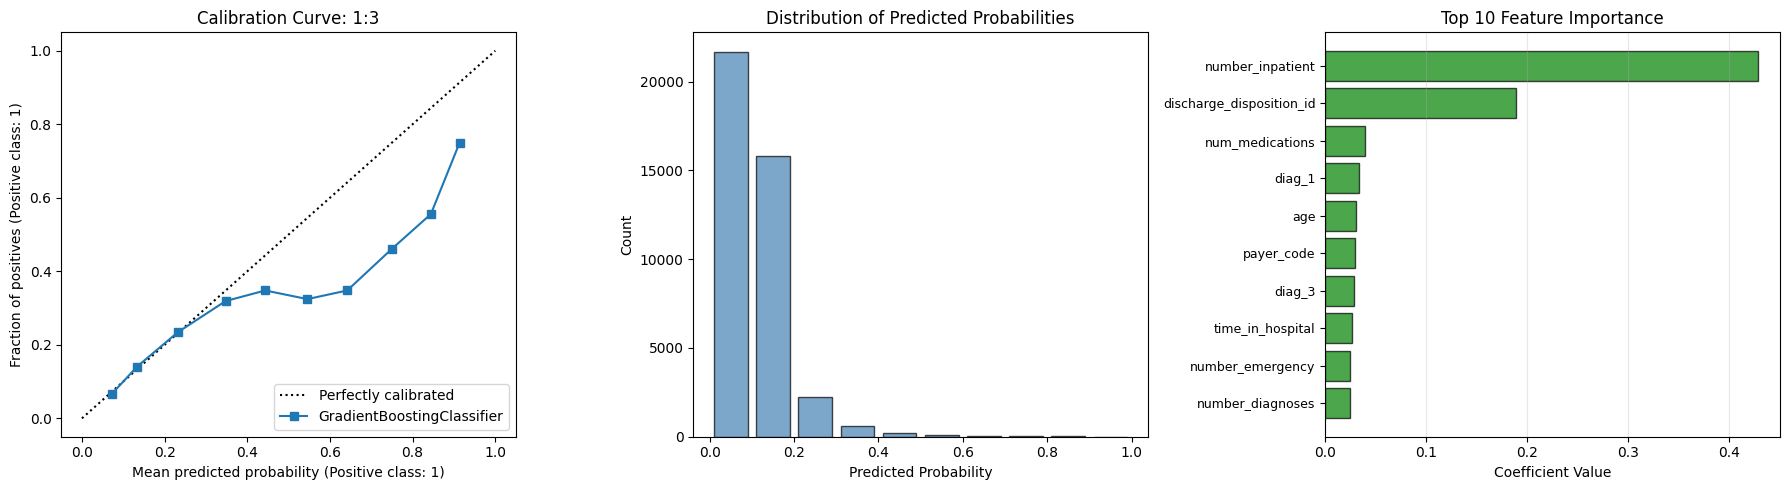

In [19]:
us = RandomUnderSampler(sampling_strategy=us_dict, random_state=0)
X_us, y_us = us.fit_resample(X_cv_train, y_cv_train)

cw = define_weights(np.mean(y_us))
sample_w = np.where(y_us == 0, cw[0], cw[1])

model = GradientBoostingClassifier(random_state=0)
model.fit(X_us, y_us, sample_weight=sample_w)
probs = model.predict_proba(X_test)[:, 1]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Calibration curve
CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=axes[0])
axes[0].set_title('Calibration Curve: 1:3')

# Plot 2: Bar plot of predicted probabilities
bins = np.linspace(0, 1, 11)
counts, _ = np.histogram(probs, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = 0.08

axes[1].bar(bin_centers, counts, width=bin_width, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predicted Probabilities')

# Plot 3: Feature importance (top 10 features)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', key=abs, ascending=False).head(10)

feature_importance_sorted = feature_importance.sort_values('importance')

axes[2].barh(range(len(feature_importance_sorted)), feature_importance_sorted['importance'], 
            color=['green' if x > 0 else 'red' for x in feature_importance_sorted['importance']],
            edgecolor='black', alpha=0.7)
axes[2].set_yticks(range(len(feature_importance_sorted)))
axes[2].set_yticklabels(feature_importance_sorted['feature'], fontsize=9)
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('Top 10 Feature Importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
outputdir="../../mlid-book/resources/ch5/ch5-3.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()